This is a very interesting task and it's very suitable for beginners, through this task you can learn about data analysis, data processing, model building, model training, parameter optimization and so on. When only use the images, with a common network, such as Resnet, Densenet, you can achieve a relatively good accuracy very easily. 

By analyzing the data, the basic information of the patient is also related to the classification of the diseased tissue. Therefore, if we can combine the case information to carry out the classification task, it will be a very meaningful work. Actually during clinical diagnosis, doctors will also combine different modal data to make comprehensive judgments.

Due to the urgency of time, my current method only uses image data, and then I will consider adding the patient's personal information to the classification task to train a more complete model. I will update my kernel immediately once I finished.

Before you really start, I strongly recommend you to read the material of pigmented lesions and dermatoscopic images[https://arxiv.org/abs/1803.10417]. After that, you can learn about the characteristics and distribution of the data from the task description and this kernel[https://www.kaggle.com/kmader/dermatology-mnist-loading-and-processing]

In this kernel I have followed following steps for model building and evaluation: 

> Step 1. Data analysis and preprocessing

> Step 2. Model building

> Step 3. Model training

> Step 4. Model evaluation

I used the pytorch framework to complete the entire task. The code contains several common networks, such as Resnet, VGG, Densenet, and Inception. You only need to make minor changes on the code to complete the network switch. Without the hyperparameter adjustment, I used **Densenet-121 to achieve an accuracy of more than 90% on the validation set in 10 epochs.**



In [1]:
import random
import torch
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# 【開発中: 速度優先】benchmark=Trueとdeterministicはどちらか一方
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

# 【再現性確保時: 上2行と入れ替え】
# torch.backends.cudnn.benchmark = False
# torch.backends.cudnn.deterministic = True

 ### First, import all libraries that used in this project

In [2]:
%matplotlib inline
# python libraties
import os, cv2,itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob
from PIL import Image

# pytorch libraries
import torch
from torch import optim,nn
# from torch.autograd import Variable  # GPU最適化で除去済み
from torch.utils.data import DataLoader,Dataset
from torchvision import models,transforms

# sklearn libraries
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

print(os.listdir("../data"))
import copy


['HAM10000_images_part_2', 'DDI', 'HAM10000_images_part_1', 'fitzpatrick17k', 'HAM10000_metadata.csv']


## Step 1. Data analysis and preprocessing

Get the all image data paths， match the row information in HAM10000_metadata.csv with its corresponding image

In [3]:
data_dir = '../data'
all_image_path = glob(os.path.join(data_dir, '*', '*.jpg'))
imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in all_image_path}

# dx短縮名 → 表示名
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

# dx短縮名 → クラスインデックス（この定義が全セルの唯一の真実）
dx_to_idx = {
    'akiec': 0,
    'bcc':   1,
    'bkl':   2,
    'df':    3,
    'mel':   4,
    'nv':    5,
    'vasc':  6,
}
idx_to_dx = {v: k for k, v in dx_to_idx.items()}
class_names = [idx_to_dx[i] for i in range(len(dx_to_idx))]
# → ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

# 結果保存先
from pathlib import Path
RESULTS_DIR = Path('../results/v3b')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Results dir: {RESULTS_DIR.resolve()}')


Results dir: /home/komai/skin-lesion-triage/results/v3b


This function is used to compute the mean and standard deviation on the whole dataset, will use for inputs normalization

In [4]:
def compute_img_mean_std(image_paths):
    """
        computing the mean and std of three channel on the whole dataset,
        first we should normalize the image from 0-255 to 0-1
    """

    img_h, img_w = 224, 224
    imgs = []
    means, stdevs = [], []

    for i in tqdm(range(len(image_paths))):
        img = cv2.imread(image_paths[i])
        img = cv2.resize(img, (img_h, img_w))
        imgs.append(img)

    imgs = np.stack(imgs, axis=3)
    print(imgs.shape)

    imgs = imgs.astype(np.float32) / 255.

    for i in range(3):
        pixels = imgs[:, :, i, :].ravel()  # resize to one row
        means.append(np.mean(pixels))
        stdevs.append(np.std(pixels))

    means.reverse()  # BGR --> RGB
    stdevs.reverse()

    print("normMean = {}".format(means))
    print("normStd = {}".format(stdevs))
    return means,stdevs

Return the mean and std of RGB channels

In [5]:
# norm_mean,norm_std = compute_img_mean_std(all_image_path)

Add three columns to the original DataFrame, path (image path), cell_type (the whole name),cell_type_idx (the corresponding index  of cell type, as the image label )

In [6]:
df_original = pd.read_csv(os.path.join(data_dir, 'HAM10000_metadata.csv'))
df_original['path'] = df_original['image_id'].map(imageid_path_dict.get)
df_original['cell_type'] = df_original['dx'].map(lesion_type_dict.get)
df_original['cell_type_idx'] = df_original['dx'].map(dx_to_idx)  # ← pd.Categoricalを廃止
df_original.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0027419.jpg,Benign keratosis-like lesions,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0025030.jpg,Benign keratosis-like lesions,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0026769.jpg,Benign keratosis-like lesions,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0025661.jpg,Benign keratosis-like lesions,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,../data/HAM10000_images_part_2/ISIC_0031633.jpg,Benign keratosis-like lesions,2


In [7]:
# this will tell us how many images are associated with each lesion_id
df_undup = df_original.groupby('lesion_id').count()
# now we filter out lesion_id's that have only one image associated with it
df_undup = df_undup[df_undup['image_id'] == 1]
df_undup.reset_index(inplace=True)
df_undup.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
0,HAM_0000001,1,1,1,1,1,1,1,1,1
1,HAM_0000003,1,1,1,1,1,1,1,1,1
2,HAM_0000004,1,1,1,1,1,1,1,1,1
3,HAM_0000007,1,1,1,1,1,1,1,1,1
4,HAM_0000008,1,1,1,1,1,1,1,1,1


In [8]:
# here we identify lesion_id's that have duplicate images and those that have only one image.
def get_duplicates(x):
    unique_list = list(df_undup['lesion_id'])
    if x in unique_list:
        return 'unduplicated'
    else:
        return 'duplicated'

# create a new colum that is a copy of the lesion_id column
df_original['duplicates'] = df_original['lesion_id']
# apply the function to this new column
df_original['duplicates'] = df_original['duplicates'].apply(get_duplicates)
df_original.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx,duplicates
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0027419.jpg,Benign keratosis-like lesions,2,duplicated
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0025030.jpg,Benign keratosis-like lesions,2,duplicated
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0026769.jpg,Benign keratosis-like lesions,2,duplicated
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0025661.jpg,Benign keratosis-like lesions,2,duplicated
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,../data/HAM10000_images_part_2/ISIC_0031633.jpg,Benign keratosis-like lesions,2,duplicated


In [9]:
df_original['duplicates'].value_counts()

duplicates
unduplicated    5514
duplicated      4501
Name: count, dtype: int64

In [10]:
# now we filter out images that don't have duplicates
df_undup = df_original[df_original['duplicates'] == 'unduplicated']
df_undup.shape

(5514, 11)

In [11]:
# ============================================================
# 3分割: train / val / test（lesion_idリーク防止）
# random_state=42 で全モデル統一
# ============================================================
y = df_undup['cell_type_idx']
df_train_undup, df_valtest = train_test_split(
    df_undup, test_size=0.2, random_state=42, stratify=y
)
df_val, df_test = train_test_split(
    df_valtest, test_size=0.5, random_state=42,
    stratify=df_valtest['cell_type_idx']
)
print(f'Undup split — train: {len(df_train_undup)}, val: {len(df_val)}, test: {len(df_test)}')


Undup split — train: 4411, val: 551, test: 552


In [12]:
df_val['cell_type_idx'].value_counts()

cell_type_idx
5    441
2     44
4     23
1     17
0     15
6      7
3      4
Name: count, dtype: int64

In [13]:
# ============================================================
# train = 全画像 − val − test（lesion_id重複ありはtrain行き）
# ============================================================
val_ids = set(df_val['image_id'])
test_ids = set(df_test['image_id'])
df_train = df_original[
    ~df_original['image_id'].isin(val_ids | test_ids)
]
print(f'Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}')
print(f'Total: {len(df_train) + len(df_val) + len(df_test)} (original: {len(df_original)})')


Train: 8912, Val: 551, Test: 552
Total: 10015 (original: 10015)


In [14]:
df_train['cell_type_idx'].value_counts()

cell_type_idx
5    5822
4    1067
2    1011
1     479
0     297
6     129
3     107
Name: count, dtype: int64

In [15]:
df_val['cell_type'].value_counts()

cell_type
Melanocytic nevi                 441
Benign keratosis-like lesions     44
Melanoma                          23
Basal cell carcinoma              17
Actinic keratoses                 15
Vascular lesions                   7
Dermatofibroma                     4
Name: count, dtype: int64

**From From the above statistics of each category, we can see that there is a serious class imbalance in the training data. To solve this problem, I think we can start from two aspects, one is equalization sampling, and the other is a loss function that can be used to mitigate category imbalance during training, such as focal loss.**

In [16]:
# train splitのみからチャネル統計量を算出（val情報のリーク防止）
train_image_paths = list(df_train['path'])
norm_mean, norm_std = compute_img_mean_std(train_image_paths)
print(f"NORM_MEAN = {[round(x, 3) for x in norm_mean]}")
print(f"NORM_STD  = {[round(x, 3) for x in norm_std]}")

# json保存
import json as _json
_json.dump(
    {"norm_mean": [round(float(x), 6) for x in norm_mean],
     "norm_std":  [round(float(x), 6) for x in norm_std]},
    open(RESULTS_DIR / 'norm_stats_v3b.json', 'w'), indent=2
)
print(f'Saved: {RESULTS_DIR}/norm_stats_v3b.json')


100%|████████████████████████████████████| 8912/8912 [00:28<00:00, 314.95it/s]


(224, 224, 3, 8912)
normMean = [np.float32(0.75806314), np.float32(0.5482086), np.float32(0.5736385)]
normStd = [np.float32(0.141923), np.float32(0.15296954), np.float32(0.17066598)]
NORM_MEAN = [np.float32(0.758), np.float32(0.548), np.float32(0.574)]
NORM_STD  = [np.float32(0.142), np.float32(0.153), np.float32(0.171)]
Saved: ../results/v3b/norm_stats_v3b.json


In [17]:
# ============================================================
# v3b: WeightedRandomSampler + Focal Loss + CB weights
# v2では data_aug_rate = [15,10,5,50,5,0,40] で行を物理コピーしていた。
# v3aと同じWeightedRandomSamplerを使用。
# 1/class_count で重みを自動計算する。
# ============================================================
from torch.utils.data import WeightedRandomSampler

# クラスごとの枚数を取得（augmentation前の元データ）
class_counts = df_train['cell_type_idx'].value_counts().sort_index().values
print('Train class counts (before sampling):')
for idx, count in enumerate(class_counts):
    print(f'  class {idx}: {count}')

# 各サンプルの重み = 1 / そのサンプルが属するクラスの枚数
sample_weights = [1.0 / class_counts[label] for label in df_train['cell_type_idx']]
sample_weights = torch.DoubleTensor(sample_weights)

# WeightedRandomSampler: 復元抽出で少数クラスが期待値として均等に選ばれる
# ※ 1epochの学習量は元データ長に揃える（学習量増加はさせない標準設定）
num_samples = len(df_train)

# 旧設定（各クラスを最大クラスと同回数見る＝1epochが重くなる）
# num_samples = int(len(class_counts) * max(class_counts))  # 全クラスがnvと同回数出現

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=num_samples,
    replacement=True
)

print(f'\nWeightedRandomSampler created: num_samples={num_samples}, replacement=True')
print(f'Expected samples per class per epoch: ~{num_samples//7}')


Train class counts (before sampling):
  class 0: 297
  class 1: 479
  class 2: 1011
  class 3: 107
  class 4: 1067
  class 5: 5822
  class 6: 129

WeightedRandomSampler created: num_samples=8912, replacement=True
Expected samples per class per epoch: ~1273


At the beginning, I divided the data into three parts, training set, validation set and test set. Considering the small amount of data, I did not further divide the validation set data in practice.

In [18]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)


## Step 2. Model building

In [19]:
# feature_extract is a boolean that defines if we are finetuning or feature extracting. 
# If feature_extract = False, the model is finetuned and all model parameters are updated. 
# If feature_extract = True, only the last layer parameters are updated, the others remain fixed.
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

In [20]:
# ============================================================
# CNN (Convolutional Neural Network) モデルの初期化
# ------------------------------------------------------------
# CNNは画像認識に特化したニューラルネットワーク。
# 小さなフィルター（例：3×3）を画像上でスライドさせて特徴を抽出する（=畳み込み）。
# 浅い層→エッジや色の境界、深い層→「ほくろっぽい形」等の高レベル概念を検出。
# 最終層で「この画像はクラスAの確率○%...」と分類する。
#
# 以下の全モデル（ResNet, VGG, DenseNet, Inception, EfficientNet）はCNNの一種。
# 違いは層のつなぎ方やスケーリング方法であり、基本構造は同じ。
#
# Transfer Learning:
#   ImageNet（一般画像1.28M枚）で学習済みの特徴抽出能力を流用し、
#   最終分類層だけ「皮膚疾患7クラス」に差し替えて再学習する。
# ============================================================
def initialize_model(model_name, num_classes, feature_extract, use_pretrained=True):
    model_ft = None
    input_size = 0
    if model_name == "resnet":
        # ResNet50: 残差接続（skip connection）で勾配消失を防ぐ。2015年。
        model_ft = models.resnet50(weights='IMAGENET1K_V1' if use_pretrained else None)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs, num_classes)  # 最終全結合層を7クラスに差替
        input_size = 224
    elif model_name == "vgg":
        # VGG11: 小さい3×3フィルターを深く積む素朴な設計。2014年。パラメータ数が多い。
        model_ft = models.vgg11_bn(weights='IMAGENET1K_V1' if use_pretrained else None)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier[6].in_features
        model_ft.classifier[6] = nn.Linear(num_ftrs, num_classes)  # classifier層の最後を差替
        input_size = 224
    elif model_name == "densenet":
        # DenseNet-121: 各層が以前の全層の出力を受け取る（Dense Connection）。
        # 勾配が消えにくく特徴の再利用効率が高い。2017年。8.0Mパラメータ。
        # → このNotebookの元々のベースラインモデル（val acc 0.895）
        model_ft = models.densenet121(weights='IMAGENET1K_V1' if use_pretrained else None)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier.in_features
        model_ft.classifier = nn.Linear(num_ftrs, num_classes)  # classifierが直接Linear
        input_size = 224
    elif model_name == "inception":
        # Inception v3: 複数サイズのフィルターを並列実行。Esteva論文で使用。2015年。
        # 入力サイズが299×299で他と異なる。補助出力（AuxLogits）も差替が必要。
        model_ft = models.inception_v3(weights='IMAGENET1K_V1' if use_pretrained else None)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.AuxLogits.fc.in_features
        model_ft.AuxLogits.fc = nn.Linear(num_ftrs, num_classes)
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs, num_classes)
        input_size = 299
    elif model_name == "efficientnet":
        # EfficientNet-B0: 幅・深さ・解像度を最適バランスで同時スケール。2019年。
        # DenseNetより少ないパラメータ（5.3M）で同等以上の精度。
        # → DenseNetベースラインとの比較用に追加
        # classifier構造: Sequential(Dropout[0] → Linear[1]) なので[1]を差替
        model_ft = models.efficientnet_b0(weights='IMAGENET1K_V1')
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier[1].in_features
        model_ft.classifier[1] = nn.Linear(num_ftrs, num_classes)
        input_size = 224
    else:
        print("Invalid model name, exiting...")
        exit()
    return model_ft, input_size

You can change your backbone network, here are 4 different networks, each network also has sevaral versions. Considering the limited training data, we used the ImageNet pre-training model for fine-tuning. This can speed up the convergence of the model and improve the accuracy.

There is one thing you need to pay attention to, the input size of Inception is different from the others (299x299), you need to change the setting of compute_img_mean_std() function 

In [21]:
# ============================================================
# モデル切替手順
# ------------------------------------------------------------
# 1. model_nameを変更（'densenet' or 'efficientnet'）
# 2. Kernel → Restart Kernel and Run All Cells で全セル実行
#    ※途中セルだけ再実行するとシード状態がずれて比較条件が崩れる
# 3. 結果を experiments/training_log.md に記録
# ============================================================
model_name = 'densenet'
num_classes = 7
feature_extract = False
model_ft, input_size = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)

# GPU自動判定 + DataParallel
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
n_gpu = torch.cuda.device_count()
print(f'Using device: {device} | GPUs available: {n_gpu}')
for i in range(n_gpu):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

model = model_ft.to(device)
del model_ft  # VRAM管理: CPU側コピー参照を解放

if n_gpu > 1:
    model = nn.DataParallel(model)
    print(f'DataParallel enabled: using {n_gpu} GPUs')


Using device: cuda:0 | GPUs available: 2
  GPU 0: NVIDIA GeForce RTX 3080
  GPU 1: NVIDIA GeForce RTX 3080
DataParallel enabled: using 2 GPUs


In [22]:
# define the transformation of the train images.
train_transform = transforms.Compose([transforms.Resize((input_size,input_size)),transforms.RandomHorizontalFlip(),
                                      transforms.RandomVerticalFlip(),transforms.RandomRotation(20),
                                      transforms.ColorJitter(brightness=0.1, contrast=0.1, hue=0.1),
                                        transforms.ToTensor(), transforms.Normalize(norm_mean, norm_std)])
# define the transformation of the val images.
val_transform = transforms.Compose([transforms.Resize((input_size,input_size)), transforms.ToTensor(),
                                    transforms.Normalize(norm_mean, norm_std)])

In [23]:
# Define a pytorch dataloader for this dataset
class HAM10000(Dataset):
    """HAM10000 Dataset for PyTorch DataLoader.
    - iloc: positional indexing to prevent index alignment bugs
    - .convert('RGB'): ensure 3-channel input regardless of source format
    - explicit file handle close via context manager
    """
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]  # positional indexing
        with Image.open(row['path']) as img:
            X = img.convert('RGB').copy()  # RGB保証 + ハンドル解放
        y = torch.tensor(int(row['cell_type_idx']))

        if self.transform:
            X = self.transform(X)

        return X, y

In [24]:
# --- 再現性用のworker設定 ---
def seed_worker(worker_id):
    worker_seed = 42 + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g_train = torch.Generator()
g_train.manual_seed(42)

g_val = torch.Generator()
g_val.manual_seed(42)

g_test = torch.Generator()
g_test.manual_seed(42)

training_set = HAM10000(df_train, transform=train_transform)
# v3b: samplerを使うためshuffle=Trueは指定しない（排他）
train_loader = DataLoader(
    training_set, batch_size=128, sampler=sampler, num_workers=4,
    pin_memory=True,
    worker_init_fn=seed_worker, generator=g_train,
)
validation_set = HAM10000(df_val, transform=val_transform)
val_loader = DataLoader(
    validation_set, batch_size=128, shuffle=False, num_workers=4,
    pin_memory=True,
    worker_init_fn=seed_worker, generator=g_val,
)
test_set = HAM10000(df_test, transform=val_transform)
test_loader = DataLoader(
    test_set, batch_size=128, shuffle=False, num_workers=4,
    pin_memory=True,
    worker_init_fn=seed_worker, generator=g_test,
)
print(f'DataLoaders — train: {len(train_loader)} batches, val: {len(val_loader)} batches, test: {len(test_loader)} batches')


DataLoaders — train: 70 batches, val: 5 batches, test: 5 batches


In [25]:
# ============================================================
# v3b変更点（v3aからの差分1箇所）: CE → Focal Loss + CB weights
# - Focal Loss (γ=2): 簡単なサンプルの損失を抑え、難サンプルに集中
# - CB weights (β=0.99): クラス間の枚数差を補正（Cui et al., CVPR 2019）
# ============================================================
import torch.nn.functional as F

# --- Class-Balanced Weights (Cui et al., CVPR 2019) ---
# w_i = (1 - β) / (1 - β^n_i)  ※augmentation前の元カウントから算出
beta = 0.99
cb_weights = (1 - beta) / (1 - beta ** class_counts)
cb_weights = cb_weights / cb_weights.sum() * len(class_counts)  # 合計=クラス数に正規化
cb_weights = torch.FloatTensor(cb_weights).to(device)
print('CB weights (β=0.99):')
for idx, (count, w) in enumerate(zip(class_counts, cb_weights)):
    print(f'  class {idx}: count={count}, weight={w:.4f}')

# --- Focal Loss (Lin et al., ICCV 2017) ---
# FL(p) = -(1-p)^γ × CE(p)  ※γ=2が標準
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        if alpha is not None:
            self.register_buffer('alpha', alpha)
        else:
            self.alpha = None

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        loss = ((1 - pt) ** self.gamma) * ce_loss
        return loss.mean() if self.reduction == 'mean' else loss.sum()

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = FocalLoss(alpha=cb_weights, gamma=2.0).to(device)
print(f'\nFocalLoss(gamma=2.0) + CB weights(beta={beta})')

# LR Scheduler: val lossが3epoch改善しなければLRを1/10に減衰
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)


CB weights (β=0.99):
  class 0: count=297, weight=0.9267
  class 1: count=479, weight=0.8871
  class 2: count=1011, weight=0.8799
  class 3: count=107, weight=1.3355
  class 4: count=1067, weight=0.8799
  class 5: count=5822, weight=0.8799
  class 6: count=129, weight=1.2111

FocalLoss(gamma=2.0) + CB weights(beta=0.99)


## Step 3. Model training

In [26]:
# this function is used during training process, to calculation the loss and accuracy
class AverageMeter(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [27]:
total_loss_train, total_acc_train = [],[]
def train(train_loader, model, criterion, optimizer, epoch):
    model.train()
    train_loss = AverageMeter()
    train_acc = AverageMeter()
    curr_iter = (epoch - 1) * len(train_loader)
    for i, data in enumerate(train_loader):
        images, labels = data
        N = images.size(0)
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        prediction = outputs.max(1, keepdim=True)[1]
        train_acc.update(prediction.eq(labels.view_as(prediction)).sum().item()/N)
        train_loss.update(loss.item())
        curr_iter += 1
        if (i + 1) % 100 == 0:
            print('[epoch %d], [iter %d / %d], [train loss %.5f], [train acc %.5f]' % (
                epoch, i + 1, len(train_loader), train_loss.avg, train_acc.avg))
            total_loss_train.append(train_loss.avg)
            total_acc_train.append(train_acc.avg)
    return train_loss.avg, train_acc.avg


In [28]:
def validate(val_loader, model, criterion, optimizer, epoch):
    model.eval()
    val_loss = AverageMeter()
    val_acc = AverageMeter()
    with torch.no_grad():
        for i, data in enumerate(val_loader):
            images, labels = data
            N = images.size(0)
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            prediction = outputs.max(1, keepdim=True)[1]

            val_acc.update(prediction.eq(labels.view_as(prediction)).sum().item()/N)

            val_loss.update(criterion(outputs, labels).item())

    print('------------------------------------------------------------')
    print('[epoch %d], [val loss %.5f], [val acc %.5f]' % (epoch, val_loss.avg, val_acc.avg))
    print('------------------------------------------------------------')
    return val_loss.avg, val_acc.avg


In [29]:
import time
import copy
import gc

training_start = time.time()

epoch_num = 50
early_stopping_patience = 7

best_val_acc = 0
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(
    model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
)
epochs_no_improve = 0
total_loss_val, total_acc_val = [],[]

for epoch in range(1, epoch_num+1):
    loss_train, acc_train = train(train_loader, model, criterion, optimizer, epoch)
    loss_val, acc_val = validate(val_loader, model, criterion, optimizer, epoch)
    total_loss_train.append(loss_train)
    total_acc_train.append(acc_train)
    total_loss_val.append(loss_val)
    total_acc_val.append(acc_val)

    scheduler.step(loss_val)

    if loss_val < best_val_loss:
        best_val_loss = loss_val
        best_val_acc = acc_val
        best_model_wts = copy.deepcopy(
            model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        )
        epochs_no_improve = 0
        print('*****************************************************')
        print('best record: [epoch %d], [val loss %.5f], [val acc %.5f]' % (epoch, loss_val, acc_val))
        print('*****************************************************')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
            print(f'\nEarly stopping at epoch {epoch} (no val_loss improvement for {early_stopping_patience} epochs)')
            break

if hasattr(model, 'module'):
    model.module.load_state_dict(best_model_wts)
else:
    model.load_state_dict(best_model_wts)

del best_model_wts
gc.collect()
torch.cuda.empty_cache()

training_time = time.time() - training_start
print(f'\nRestored best model weights (val loss {best_val_loss:.5f}, val acc {best_val_acc:.5f})')
print(f'Training time: {training_time/60:.1f} min ({training_time:.0f} sec)')
print(f'Stopped at epoch {min(epoch, epoch_num)} / {epoch_num}')


------------------------------------------------------------
[epoch 1], [val loss 0.40809], [val acc 0.76122]
------------------------------------------------------------
*****************************************************
best record: [epoch 1], [val loss 0.40809], [val acc 0.76122]
*****************************************************
------------------------------------------------------------
[epoch 2], [val loss 0.16956], [val acc 0.86943]
------------------------------------------------------------
*****************************************************
best record: [epoch 2], [val loss 0.16956], [val acc 0.86943]
*****************************************************
------------------------------------------------------------
[epoch 3], [val loss 0.19007], [val acc 0.81230]
------------------------------------------------------------
------------------------------------------------------------
[epoch 4], [val loss 0.26679], [val acc 0.73510]
-------------------------------------

## Step 4. Model evaluation

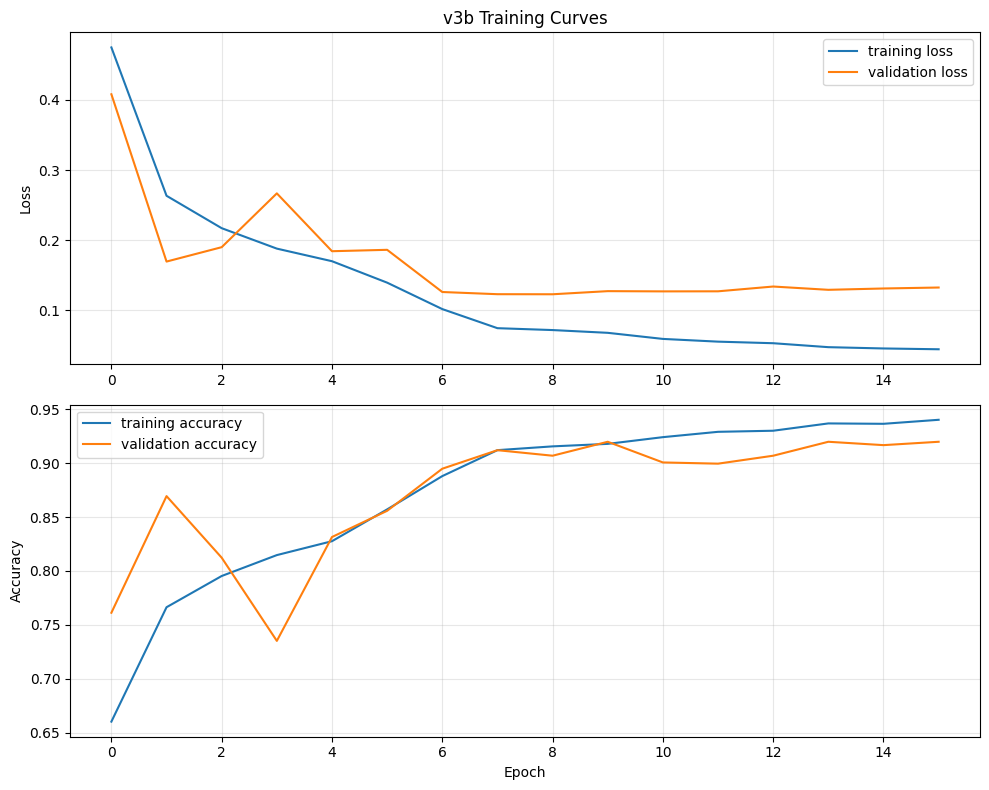

Saved: ../results/v3b/fig_training_curves.png


In [30]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
ax1.plot(total_loss_train, label='training loss')
ax1.plot(total_loss_val, label='validation loss')
ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.set_title('v3b Training Curves')
ax2.plot(total_acc_train, label='training accuracy')
ax2.plot(total_acc_val, label='validation accuracy')
ax2.set_ylabel('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR}/fig_training_curves.png')


In [31]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')


 VAL SET EVALUATION
  → Saved: ../results/v3b/fig_confusion_matrix_val.png


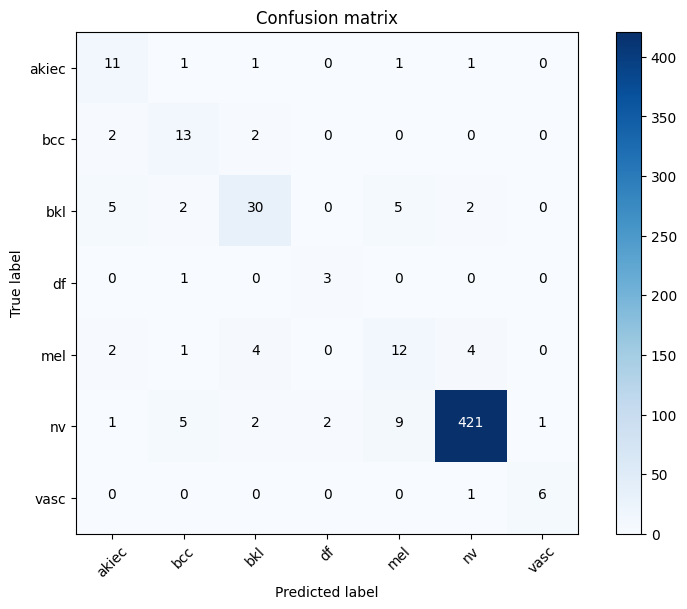

              precision    recall  f1-score   support

       akiec       0.52      0.73      0.61        15
         bcc       0.57      0.76      0.65        17
         bkl       0.77      0.68      0.72        44
          df       0.60      0.75      0.67         4
         mel       0.44      0.52      0.48        23
          nv       0.98      0.95      0.97       441
        vasc       0.86      0.86      0.86         7

    accuracy                           0.90       551
   macro avg       0.68      0.75      0.71       551
weighted avg       0.91      0.90      0.90       551

  → Saved: ../results/v3b/classification_report_val.txt
ROC-AUC (macro, OvR): 0.9668
  akiec: 0.9874
  bcc: 0.9874
  bkl: 0.9478
  df: 0.9644
  mel: 0.9196
  nv: 0.9871
  vasc: 0.9737

 TEST SET EVALUATION
  → Saved: ../results/v3b/fig_confusion_matrix_test.png


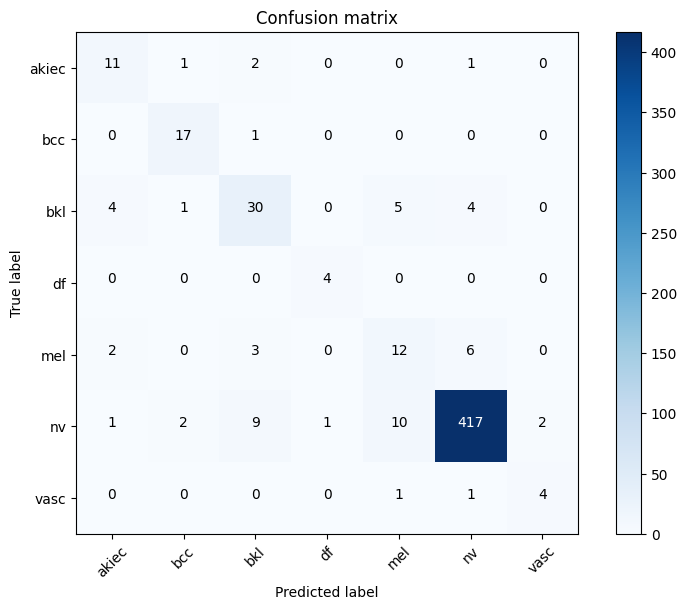

              precision    recall  f1-score   support

       akiec       0.61      0.73      0.67        15
         bcc       0.81      0.94      0.87        18
         bkl       0.67      0.68      0.67        44
          df       0.80      1.00      0.89         4
         mel       0.43      0.52      0.47        23
          nv       0.97      0.94      0.96       442
        vasc       0.67      0.67      0.67         6

    accuracy                           0.90       552
   macro avg       0.71      0.78      0.74       552
weighted avg       0.91      0.90      0.90       552

  → Saved: ../results/v3b/classification_report_test.txt
ROC-AUC (macro, OvR): 0.9723
  akiec: 0.9851
  bcc: 0.9963
  bkl: 0.9464
  df: 1.0000
  mel: 0.9116
  nv: 0.9812
  vasc: 0.9853


In [32]:
# ============================================================
# 統合評価セル: val + test 両方を評価、結果をファイル保存
# ============================================================
import torch.nn.functional as F
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

def evaluate_loader(loader, model, device, split_name="val", results_dir=None):
    """1回の推論ループで予測ラベル・softmax確率を同時取得"""
    y_true, y_pred, y_prob = [], [], []
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            prediction = outputs.max(1, keepdim=True)[1]
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(np.squeeze(prediction.cpu().numpy().T))
            probs = F.softmax(outputs, dim=1)
            y_prob.extend(probs.cpu().numpy())
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    # ---- Confusion Matrix ----
    confusion_mtx = confusion_matrix(y_true, y_pred)
    print(f'\n{"="*60}')
    print(f' {split_name.upper()} SET EVALUATION')
    print(f'{"="*60}')
    plt.figure(figsize=(8, 6))
    plot_confusion_matrix(confusion_mtx, class_names)
    if results_dir:
        plt.savefig(results_dir / f'fig_confusion_matrix_{split_name}.png', dpi=150, bbox_inches='tight')
        print(f'  → Saved: {results_dir}/fig_confusion_matrix_{split_name}.png')
    plt.show()

    # ---- Classification Report ----
    report_str = classification_report(y_true, y_pred, target_names=class_names)
    print(report_str)
    if results_dir:
        with open(results_dir / f'classification_report_{split_name}.txt', 'w') as f:
            f.write(report_str)
        print(f'  → Saved: {results_dir}/classification_report_{split_name}.txt')

    # ---- ROC-AUC (macro, One-vs-Rest) ----
    y_true_onehot = label_binarize(y_true, classes=range(7))
    roc_auc = roc_auc_score(y_true_onehot, y_prob, multi_class='ovr', average='macro')
    print(f"ROC-AUC (macro, OvR): {roc_auc:.4f}")
    for i, name in enumerate(class_names):
        auc_i = roc_auc_score(y_true_onehot[:, i], y_prob[:, i])
        print(f"  {name}: {auc_i:.4f}")

    return y_true, y_pred, y_prob, confusion_mtx, roc_auc

# Val評価（TS最適化・閾値最適化のベース）
y_true, y_pred, y_prob, confusion_mtx, roc_auc = evaluate_loader(
    val_loader, model, device, "val", RESULTS_DIR)

# Test評価（最終報告用 — 一切の最適化に使わない）
y_true_test, y_pred_test, y_prob_test, confusion_mtx_test, roc_auc_test = evaluate_loader(
    test_loader, model, device, "test", RESULTS_DIR)


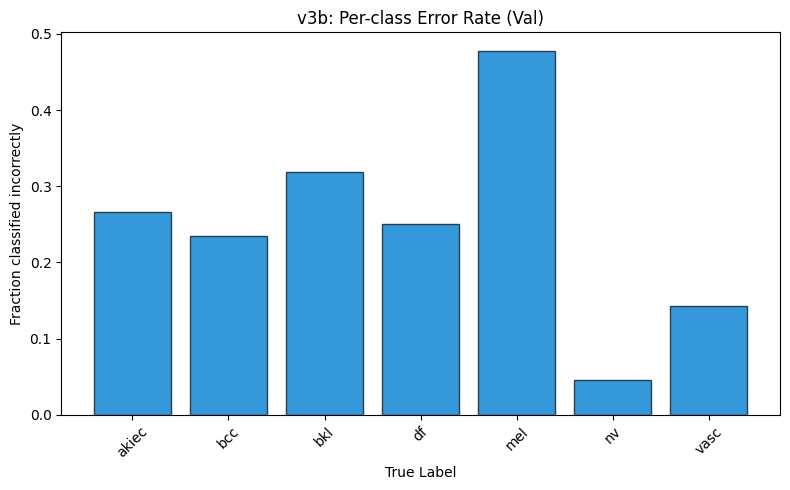

Saved: ../results/v3b/fig_error_rate_val.png


In [33]:
# Val error fraction per class
label_frac_error = 1 - np.diag(confusion_mtx) / np.sum(confusion_mtx, axis=1)
plt.figure(figsize=(8, 5))
plt.bar(np.arange(7), label_frac_error, color='#3498db', edgecolor='#2c3e50')
plt.xticks(np.arange(7), class_names, rotation=45)
plt.xlabel('True Label')
plt.ylabel('Fraction classified incorrectly')
plt.title('v3b: Per-class Error Rate (Val)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_error_rate_val.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR}/fig_error_rate_val.png')


## Conclusion

I tried to train with different network structures. When using Densenet-121, the average accuracy of 7 classes on the validation set can reach 92% in 10 epochs. We also calculated the confusion matrix for all classes and the F1-score for each class, which is a more comprehensive indicator that can take into account both the precision and recall of the classification model.Our model can achieve more than 90% on the F1-score indicator.

Due to limited time, we did not spend much time on model training. By increasing in training epochs, adjustmenting of model hyperparameters, and attempting at different networks may further enhance the performance of the model.

## Next plan

How to use image data and patient case data at the same time, my plan is to use CNN to extract features from images, use xgboost to convert medical records into vectors and then concat them with CNN network full-layer features. Two branch networks are trained simultaneously using a loss function. We can refer to the methods used in the advertising CTR estimation task.

In [34]:
import os
from datetime import datetime

os.makedirs('../models', exist_ok=True)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
save_path = f'../models/densenet_v3b_{timestamp}.pth'  # v3b: ファイル名変更

# DataParallel時は model.module.state_dict() で保存（module.プレフィックスを除去）
state_dict = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
torch.save(state_dict, save_path)
size_mb = os.path.getsize(save_path) / 1e6
print(f"保存完了: {save_path} ({size_mb:.1f} MB)")
print(f"  model: {model_name}")
print(f"  config: WeightedRandomSampler + FocalLoss(gamma=2) + CB weights(beta=0.99)")
print(f"  best val acc: {best_val_acc:.5f}")


保存完了: ../models/densenet_v3b_20260311_182540.pth (28.5 MB)
  model: densenet
  config: WeightedRandomSampler + FocalLoss(gamma=2) + CB weights(beta=0.99)
  best val acc: 0.90693


In [35]:
# ============================================================
# SAVE: val + test 推論結果を保存
# val: TS未適用（raw softmax）
# test: TS未適用（raw softmax）— v3bはpost-hoc最適化の対象外だが形式統一
# ============================================================
NB_NAME = 'v3b'
_nb_name = os.path.splitext(os.path.basename(__vsc_ipynb_file__ if '__vsc_ipynb_file__' in dir() else NB_NAME))[0]
os.makedirs('../results/models', exist_ok=True)

model.eval()

# --- val推論 ---
_val_logits, _val_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device, non_blocking=True)
        logits = model(images)
        _val_logits.append(logits.cpu())
        _val_labels.append(labels)

_val_logits = torch.cat(_val_logits, dim=0)
_val_labels = torch.cat(_val_labels, dim=0)

_val_path = f'../results/models/{_nb_name}_val_predictions.npz'
np.savez(
    _val_path,
    all_probs=F.softmax(_val_logits, dim=1).numpy(),
    y_true=_val_labels.numpy(),
    all_logits=_val_logits.numpy(),
)
print(f"Saved val npz to {_val_path} ✓")

# --- test推論 ---
_test_logits, _test_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        logits = model(images)
        _test_logits.append(logits.cpu())
        _test_labels.append(labels)

_test_logits = torch.cat(_test_logits, dim=0)
_test_labels = torch.cat(_test_labels, dim=0)

_test_path = f'../results/models/{_nb_name}_test_predictions.npz'
np.savez(
    _test_path,
    all_probs=F.softmax(_test_logits, dim=1).numpy(),
    y_true=_test_labels.numpy(),
    all_logits=_test_logits.numpy(),
)
print(f"Saved test npz to {_test_path} ✓")


Saved val npz to ../results/models/v3b_val_predictions.npz ✓
Saved test npz to ../results/models/v3b_test_predictions.npz ✓


In [36]:
# ============================================================
# 実験ログ出力（docs/04_実験ログ.md に追記）
# ============================================================
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
from datetime import datetime

# --- Val metrics ---
y_true_onehot = label_binarize(y_true, classes=range(7))
per_class_auc = {name: roc_auc_score(y_true_onehot[:, i], y_prob[:, i])
                 for i, name in enumerate(class_names)}
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
cm_str = np.array2string(confusion_mtx, separator=', ')

# --- Test metrics ---
y_true_test_onehot = label_binarize(y_true_test, classes=range(7))
per_class_auc_test = {name: roc_auc_score(y_true_test_onehot[:, i], y_prob_test[:, i])
                      for i, name in enumerate(class_names)}
report_test = classification_report(y_true_test, y_pred_test, target_names=class_names, output_dict=True)
roc_auc_test_val = roc_auc_score(y_true_test_onehot, y_prob_test, multi_class='ovr', average='macro')
cm_test_str = np.array2string(confusion_mtx_test, separator=', ')

rows_val = ''
for name in class_names:
    r = report[name]
    rows_val += f"| {name} | {r['precision']:.4f} | {r['recall']:.4f} | {r['f1-score']:.4f} | {per_class_auc[name]:.4f} |\n"
rows_test = ''
for name in class_names:
    r = report_test[name]
    rows_test += f"| {name} | {r['precision']:.4f} | {r['recall']:.4f} | {r['f1-score']:.4f} | {per_class_auc_test[name]:.4f} |\n"

lines = [
    '',
    '## v3b: DenseNet-121 WeightedRandomSampler + FocalLoss(γ=2) + CB weights(β=0.99)',
    f'- **日付**: {datetime.now().strftime("%Y-%m-%d")}',
    f'- **モデル**: DenseNet-121 (densenet_v3b_*.pth)',
    f'- **損失関数**: FocalLoss(gamma=2) + CB weights(beta=0.99)',
    f'- **サンプリング**: WeightedRandomSampler (num_samples=len(df_train))',
    f'- **分割**: train/val/test 3分割 (random_state=42)',
    f'- **Early stopping**: patience=7 (val_loss監視)',
    f'- **学習時間**: {training_time/60:.1f} min ({training_time:.0f} sec)',
    f'- **停止エポック**: {min(epoch, epoch_num)} / {epoch_num}',
    f'- **Best val loss**: {best_val_loss:.5f}',
    f'- **Best val acc**: {best_val_acc:.5f}',
    '',
    '### Val評価 (7クラス、argmax)',
    '| クラス | Precision | Recall | F1 | AUC (OvR) |',
    '| ------ | --------- | ------ | -- | --------- |',
    rows_val + f'| **macro avg** | {report["macro avg"]["precision"]:.4f} | {report["macro avg"]["recall"]:.4f} | {report["macro avg"]["f1-score"]:.4f} | {roc_auc:.4f} |',
    '',
    '### Test評価 (7クラス、argmax)',
    '| クラス | Precision | Recall | F1 | AUC (OvR) |',
    '| ------ | --------- | ------ | -- | --------- |',
    rows_test + f'| **macro avg** | {report_test["macro avg"]["precision"]:.4f} | {report_test["macro avg"]["recall"]:.4f} | {report_test["macro avg"]["f1-score"]:.4f} | {roc_auc_test_val:.4f} |',
    '',
    f'- **[Val] ROC-AUC macro**: {roc_auc:.4f}',
    f'- **[Test] ROC-AUC macro**: {roc_auc_test_val:.4f}',
    '',
    '### 混同行列 (Val)',
    '```',
    cm_str,
    '```',
    '### 混同行列 (Test)',
    '```',
    cm_test_str,
    '```',
    '',
    '### 成果物',
    f'- モデル: `{save_path}`',
    f'- Val推論結果: `../results/models/v3b_val_predictions.npz`',
    f'- Test推論結果: `../results/models/v3b_test_predictions.npz`',
    '',
    f'- 結果ディレクトリ: `../results/v3b/`',
    f'  - fig_training_curves.png',
    f'  - fig_confusion_matrix_val.png / test.png',
    f'  - fig_error_rate_val.png',
    f'  - classification_report_val.txt / test.txt',
    f'  - norm_stats_v3b.json',
    f'  - experiment_log_v3b.md',
    '',
    '### 判断・メモ',
    '- 3分割修正（train/val/test）適用済み',
    '- v3a (CE) との比較で採用モデルを決定',
    '',
]
log_text = '\n'.join(lines)
print(log_text)

with open(RESULTS_DIR / 'experiment_log_v3b.md', 'w') as f:
    f.write(log_text)
print(f'\nSaved: {RESULTS_DIR}/experiment_log_v3b.md')
print('↑ docs/04_実験ログ.md にも追記してください')



## v3b: DenseNet-121 WeightedRandomSampler + FocalLoss(γ=2) + CB weights(β=0.99)
- **日付**: 2026-03-11
- **モデル**: DenseNet-121 (densenet_v3b_*.pth)
- **損失関数**: FocalLoss(gamma=2) + CB weights(beta=0.99)
- **サンプリング**: WeightedRandomSampler (num_samples=len(df_train))
- **分割**: train/val/test 3分割 (random_state=42)
- **Early stopping**: patience=7 (val_loss監視)
- **学習時間**: 35.1 min (2104 sec)
- **停止エポック**: 16 / 50
- **Best val loss**: 0.12293
- **Best val acc**: 0.90693

### Val評価 (7クラス、argmax)
| クラス | Precision | Recall | F1 | AUC (OvR) |
| ------ | --------- | ------ | -- | --------- |
| akiec | 0.5238 | 0.7333 | 0.6111 | 0.9874 |
| bcc | 0.5652 | 0.7647 | 0.6500 | 0.9874 |
| bkl | 0.7692 | 0.6818 | 0.7229 | 0.9478 |
| df | 0.6000 | 0.7500 | 0.6667 | 0.9644 |
| mel | 0.4444 | 0.5217 | 0.4800 | 0.9196 |
| nv | 0.9814 | 0.9546 | 0.9678 | 0.9871 |
| vasc | 0.8571 | 0.8571 | 0.8571 | 0.9737 |
| **macro avg** | 0.6773 | 0.7519 | 0.7079 | 0.9668 |

### Test評価 (7クラス、argmax)
| クラス | Precision | 

In [37]:
# ============================================================
# VRAM全解放（次モデル実行に向けて）
# ============================================================
import gc
model.cpu()
del model
gc.collect()
torch.cuda.empty_cache()
print('VRAM released ✓')


VRAM released ✓
